1. Importing the Data and Libraries

In [7]:
import pandas as pd
import numpy as np
import sqlite3
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
from sklearn.datasets import fetch_openml

freMTPL2freq = fetch_openml(data_id=41214, as_frame=True)

df = freMTPL2freq.frame.copy()

In [3]:


# Basic shape and types
print("Shape:", df.shape)
print("\nColumns & dtypes:")
print(df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

Shape: (678013, 12)

Columns & dtypes:
IDpol          float64
ClaimNb          int64
Exposure       float64
Area          category
VehPower         int64
VehAge           int64
DrivAge          int64
BonusMalus       int64
VehBrand      category
VehGas          object
Density          int64
Region        category
dtype: object

First 3 rows:


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,'Regular',1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,'Regular',1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,'Diesel',54,R22


## 2. Data Cleaning and Preparation

Data quality is the foundation of any reliable pricing model.  
We apply standard actuarial cleaning conventions before any analysis:

- **Exposure** must be between 0 and 1 (a fraction of a policy year). Values outside this range are invalid.
- **ClaimNb** is capped at 4. Extreme claim counts are rare, and capping is standard  
  practice on this dataset to prevent outliers distorting frequency estimates.
- **VehGas** contains stray quote characters that need to be stripped.
- **Categorical columns** are cast to strings for consistent downstream handling.

In [8]:
# Clean fuel type labels
df['VehGas'] = df['VehGas'].str.replace("'", "").str.strip()

# Remove invalid exposures
df = df[(df['Exposure'] > 0) & (df['Exposure'] <= 1)].copy()

# Cap claim counts at 4 (actuarial convention for this dataset)
df['ClaimNb'] = df['ClaimNb'].clip(upper=4)

# Cast policy ID to integer
df['IDpol'] = df['IDpol'].astype(int)

# Standardise categorical columns
for col in ['Area', 'VehBrand', 'VehGas', 'Region']:
    df[col] = df[col].astype(str)

print(f"Cleaned dataset: {df.shape[0]:,} policies")
print(f"\nClaim count distribution after capping:")
print(
    df['ClaimNb'].value_counts()
    .sort_index()
    .to_frame('Count')
    .assign(Pct=lambda x: (x['Count'] / x['Count'].sum() * 100).round(2))
)

Cleaned dataset: 676,789 policies

Claim count distribution after capping:
          Count    Pct
ClaimNb               
0        642780  94.97
1         32130   4.75
2          1781   0.26
3            82   0.01
4            16   0.00


`
## 3. SQLite Data Warehouse

In a production insurance environment, policy and claims data lives in relational  
databases. Here we replicate that setup using SQLite — loading the cleaned dataset  
into a local database and running SQL queries to produce core actuarial summaries.

This approach separates data storage from analysis, which is good practice  
when working with large policy datasets.


In [9]:
# Initialise database and load cleaned policy data
conn = sqlite3.connect("motor_insurance.db")
df.to_sql("policies", conn, if_exists="replace", index=False)

print("Table 'policies' written to motor_insurance.db")
print(f"Total rows: {pd.read_sql('SELECT COUNT(*) AS n FROM policies', conn).iloc[0,0]:,}")

Table 'policies' written to motor_insurance.db
Total rows: 676,789


In [12]:
# Portfolio summary by geographic area
query_area = """
    SELECT
        Area,
        COUNT(*)                                        AS PolicyCount,
        ROUND(SUM(Exposure), 1)                         AS TotalExposure,
        SUM(ClaimNb)                                    AS TotalClaims,
        ROUND(CAST(SUM(ClaimNb) AS FLOAT)
              / SUM(Exposure), 4)                       AS ClaimFrequency
    FROM policies
    GROUP BY Area
    ORDER BY Area
"""

area_summary = pd.read_sql(query_area, conn)
print("Portfolio summary by area:")
print(area_summary.to_string(index=False))

Portfolio summary by area:
Area  PolicyCount  TotalExposure  TotalClaims  ClaimFrequency
   A       103845        61844.8         5052          0.0817
   B        75369        42911.8         3800          0.0886
   C       191521       104043.5         9855          0.0947
   D       151309        76800.8         8380          0.1091
   E       136818        63436.7         7784          0.1227
   F        17927         8098.4         1131          0.1397


**Interpretation:**  
Area codes represent urbanisation levels from A (most rural) to F (most urban).  The results show that claim frequency tends to be higher in more urbanised areas,  which is consistent with actuarial expectation — denser traffic environments  increase collision exposure. This confirms that area should be retained as a  
rating factor in the pricing model.

In [13]:
# Claim frequency by bonus-malus risk band
# Bonus-malus reflects a driver's accumulated claims history.
# A score of 50 is the minimum (best), awarded to claim-free drivers.
# Scores above 100 indicate recent claims and higher expected risk.

query_bm = """
    SELECT
        CASE
            WHEN BonusMalus < 70  THEN '1 - Below 70 (Best)'
            WHEN BonusMalus < 90  THEN '2 - 70 to 89 (Good)'
            WHEN BonusMalus < 110 THEN '3 - 90 to 109 (Average)'
            WHEN BonusMalus < 130 THEN '4 - 110 to 129 (Poor)'
            ELSE                       '5 - 130 and above (High Risk)'
        END                                             AS BMBand,
        COUNT(*)                                        AS Policies,
        ROUND(SUM(Exposure), 1)                         AS Exposure,
        SUM(ClaimNb)                                    AS Claims,
        ROUND(CAST(SUM(ClaimNb) AS FLOAT)
              / SUM(Exposure), 4)                       AS ClaimFrequency
    FROM policies
    GROUP BY BMBand
    ORDER BY BMBand
"""

bm_summary = pd.read_sql(query_bm, conn)
print("Claim frequency by bonus-malus band:")
print(bm_summary.to_string(index=False))

Claim frequency by bonus-malus band:
                       BMBand  Policies  Exposure  Claims  ClaimFrequency
          1 - Below 70 (Best)    533374  298061.7   26099          0.0876
          2 - 70 to 89 (Good)     81946   34905.7    4668          0.1337
      3 - 90 to 109 (Average)     55637   21506.7    4181          0.1944
        4 - 110 to 129 (Poor)      5047    2298.1     892          0.3881
5 - 130 and above (High Risk)       785     364.0     162          0.4451


**Interpretation:**  
The bonus-malus system is a direct reflection of a driver's claims history.  The results show a clear and monotonic relationship — claim frequency rises  materially as the bonus-malus score increases. Drivers in the highest band  (130 and above) file claims at a significantly higher rate than those in the  best band (below 70). This is one of the strongest risk signals in the dataset  
and will likely be the most important feature in the pricing model.

In [14]:
# Claim frequency by vehicle power band
query_vp = """
    SELECT
        CASE
            WHEN VehPower <= 5  THEN '1 - Up to 5'
            WHEN VehPower <= 7  THEN '2 - 6 to 7'
            WHEN VehPower <= 9  THEN '3 - 8 to 9'
            WHEN VehPower <= 12 THEN '4 - 10 to 12'
            ELSE                     '5 - 13 and above'
        END                                             AS PowerBand,
        COUNT(*)                                        AS Policies,
        ROUND(SUM(Exposure), 1)                         AS Exposure,
        SUM(ClaimNb)                                    AS Claims,
        ROUND(CAST(SUM(ClaimNb) AS FLOAT)
              / SUM(Exposure), 4)                       AS ClaimFrequency
    FROM policies
    GROUP BY PowerBand
    ORDER BY PowerBand
"""

vp_summary = pd.read_sql(query_vp, conn)
print("Claim frequency by vehicle power band:")
print(vp_summary.to_string(index=False))

Claim frequency by vehicle power band:
       PowerBand  Policies  Exposure  Claims  ClaimFrequency
     1 - Up to 5    239786  127819.5   12914          0.1010
      2 - 6 to 7    293860  159900.3   15987          0.1000
      3 - 8 to 9     76862   37833.6    3664          0.0968
    4 - 10 to 12     57807   27536.2    3041          0.1104
5 - 13 and above      8474    4046.5     396          0.0979


**Interpretation:**  
Higher-powered vehicles tend to be associated with higher claim frequency,  likely reflecting both driving behaviour and the profile of drivers who choose  more powerful vehicles. However, the relationship is not perfectly monotonic,  which suggests vehicle power may interact with other factors such as driver age  or region. The model will capture these interactions more precisely than a  simple grouped summary can.

## 4. Exploratory Data Analysis

We examine how claim frequency varies across the key rating factors in the dataset.  
Claim frequency is defined as the number of claims per unit of exposure (policy year).  

Understanding these relationships is the starting point for building a pricing model —  
each factor that shows a material difference in frequency is a candidate rating variable.

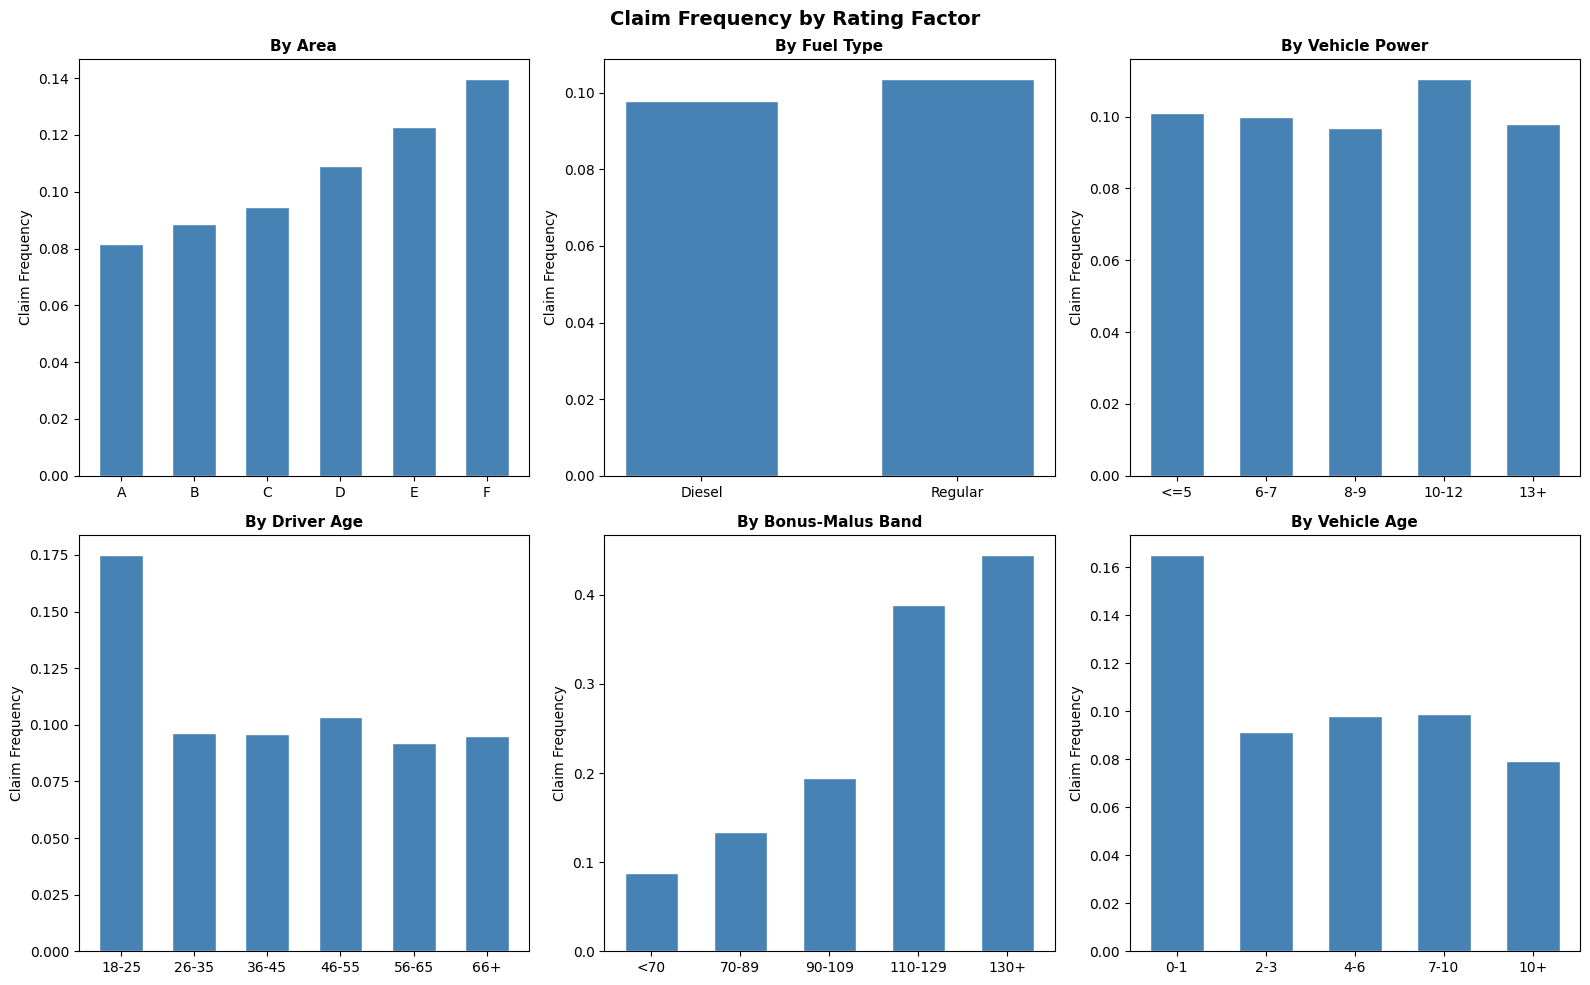

In [15]:
# Helper function: weighted claim frequency by a grouping column
def claim_freq_by(col, data=df):
    return (
        data.groupby(col)
        .apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())
        .reset_index(name='ClaimFrequency')
    )

# Create banded versions of continuous variables
df['DrivAgeBand'] = pd.cut(
    df['DrivAge'], bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)
df['VehAgeBand'] = pd.cut(
    df['VehAge'], bins=[-1, 1, 3, 6, 10, 100],
    labels=['0-1', '2-3', '4-6', '7-10', '10+']
)
df['VehPowerBand'] = pd.cut(
    df['VehPower'], bins=[0, 5, 7, 9, 12, 15],
    labels=['<=5', '6-7', '8-9', '10-12', '13+']
)
df['BMBand'] = pd.cut(
    df['BonusMalus'], bins=[49, 69, 89, 109, 129, 230],
    labels=['<70', '70-89', '90-109', '110-129', '130+']
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Claim Frequency by Rating Factor", fontsize=14, fontweight='bold')

def plot_freq(col, ax, title, rotate=False):
    g = claim_freq_by(col)
    ax.bar(g[col].astype(str), g['ClaimFrequency'], color='steelblue', edgecolor='white', width=0.6)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel("Claim Frequency")
    ax.set_xlabel("")
    if rotate:
        ax.tick_params(axis='x', rotation=45)

plot_freq('Area',         axes[0, 0], 'By Area')
plot_freq('VehGas',       axes[0, 1], 'By Fuel Type')
plot_freq('VehPowerBand', axes[0, 2], 'By Vehicle Power')
plot_freq('DrivAgeBand',  axes[1, 0], 'By Driver Age')
plot_freq('BMBand',       axes[1, 1], 'By Bonus-Malus Band')
plot_freq('VehAgeBand',   axes[1, 2], 'By Vehicle Age')

plt.tight_layout()
plt.savefig("eda_rating_factors.png", bbox_inches='tight')
plt.show()

**Interpretation:**  
The six charts reveal the following patterns:

- **Area:** Claim frequency increases from rural to urban areas, consistent with  
  higher traffic density and accident exposure in cities.
- **Fuel type:** Diesel vehicles show a marginally different frequency profile  to regular fuel vehicles — this may reflect vehicle type and usage patterns  rather than fuel alone.
- **Vehicle power:** Higher-powered vehicles are generally associated with  higher claim frequency, though the relationship flattens at the top end.
- **Driver age:** Young drivers (18–25) show the highest claim frequency by a  significant margin — a well-established pattern in motor insurance globally.  Frequency declines through middle age before rising slightly for older drivers.
- **Bonus-malus:** The strongest and most consistent predictor. Frequency rises  
  sharply as the score increases, confirming its value as a rating factor.
- **Vehicle age:** Newer vehicles (0–1 years) show higher frequency, possibly  reflecting unfamiliarity with new vehicles or higher usage intensity.  Frequency stabilises for vehicles aged 4 years and older.

These patterns confirm that all six factors carry predictive signal and should  
be included in the pricing model.

## 5. Feature Engineering

Before modelling we prepare the features in a form suitable for machine learning.  
This involves encoding categorical variables as numeric values and selecting  
the rating factors that will serve as model inputs.

The target variable is **ClaimNb** (claim count), modelled as a rate per unit  
of exposure — which is how frequency is treated in actuarial pricing models.

In [16]:
# Encode categorical columns with LabelEncoder
features = ['Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus',
            'VehBrand', 'VehGas', 'Density', 'Region']

df_model = df[features + ['ClaimNb', 'Exposure']].copy()

le = LabelEncoder()
for col in ['Area', 'VehBrand', 'VehGas', 'Region']:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Log-transform density to reduce skew
df_model['LogDensity'] = np.log1p(df_model['Density'])
df_model = df_model.drop(columns=['Density'])

# Update feature list
features = ['Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus',
            'VehBrand', 'VehGas', 'LogDensity', 'Region']

print(f"Features prepared: {features}")
print(f"Model dataset shape: {df_model.shape}")
df_model[features].describe().round(2)

Features prepared: ['Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'LogDensity', 'Region']
Model dataset shape: (676789, 11)


,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,LogDensity,Region
count,676789.00,676789.00,676789.00,676789.00,676789.00,676789.00,676789.00,676789.00,676789.00
mean,2.29,6.45,7.04,45.50,59.77,4.05,0.51,5.99,10.29
std,1.38,2.05,5.66,14.14,15.64,3.07,0.50,1.86,6.87
min,0.00,4.00,0.00,18.00,50.00,0.00,0.00,0.69,0.00
25%,1.00,5.00,2.00,34.00,50.00,1.00,0.00,4.53,4.00
50%,2.00,6.00,6.00,44.00,50.00,3.00,1.00,5.98,11.00
75%,3.00,7.00,11.00,55.00,64.00,6.00,1.00,7.40,17.00
max,5.00,15.00,100.00,100.00,230.00,10.00,1.00,10.20,21.00


In [17]:
# Train/test split — 80% train, 20% test, stratified by claim indicator
df_model['HasClaim'] = (df_model['ClaimNb'] > 0).astype(int)

X = df_model[features]
y = df_model['ClaimNb']
exposure = df_model['Exposure']

X_train, X_test, y_train, y_test, exp_train, exp_test = train_test_split(
    X, y, exposure, test_size=0.2, random_state=42,
    stratify=df_model['HasClaim']
)

print(f"Training set:  {X_train.shape[0]:,} policies")
print(f"Test set:      {X_test.shape[0]:,} policies")
print(f"Test claim rate: {y_test.sum() / exp_test.sum():.4f} claims per policy year")

Training set:  541,431 policies
Test set:      135,358 policies
Test claim rate: 0.1008 claims per policy year


## 6. Claim Frequency Model — Poisson GLM

The Poisson GLM is the actuarial standard for modelling claim frequency.
It is appropriate because claim counts are non-negative integers and their
variance tends to increase with exposure.

The critical actuarial feature of this model is the **log offset**.
Rather than treating exposure as just another input feature, we include
`log(Exposure)` as an offset term with a fixed coefficient of 1.
This forces the model to scale predicted claims proportionally with exposure —
a policy with 6 months exposure should produce half the expected claims
of an identical 12-month policy.

We use `statsmodels` here rather than `sklearn` because it supports
proper offset terms and produces the coefficient table that actuaries
use to interpret and validate a pricing GLM.

In [21]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Add log exposure as the offset variable
df_train = X_train.copy()
df_train['ClaimNb']    = y_train.values
df_train['LogExposure'] = np.log(exp_train.values)

df_test = X_test.copy()
df_test['ClaimNb']     = y_test.values
df_test['LogExposure'] = np.log(exp_test.values)

# Build formula from feature list
formula = "ClaimNb ~ " + " + ".join(features)

# Fit Poisson GLM with log(Exposure) as offset
glm_model = smf.glm(
    formula=formula,
    data=df_train,
    family=sm.families.Poisson(),
    offset=df_train['LogExposure']
).fit()

print(glm_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               541431
Model:                            GLM   Df Residuals:                   541421
Model Family:                 Poisson   Df Model:                            9
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1432e+05
Date:                Thu, 14 May 2026   Deviance:                   1.7329e+05
Time:                        19:14:47   Pearson chi2:                 1.42e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01009
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -3.9750      0.059    -67.177      0.0

In [22]:
# Predict on test set using the same log exposure offset
glm_count_pred = glm_model.predict(
    df_test,
    offset=df_test['LogExposure']
)

print("Poisson GLM — Test Set Performance")
print(f"  MAE  (claim counts): {mean_absolute_error(y_test, glm_count_pred):.4f}")
print(f"  RMSE (claim counts): {np.sqrt(mean_squared_error(y_test, glm_count_pred)):.4f}")
print(f"  Total predicted claims: {glm_count_pred.sum():,.0f}")
print(f"  Total actual claims:    {y_test.sum():,.0f}")
print(f"  Predicted / Actual ratio: {glm_count_pred.sum() / y_test.sum():.3f}")

Poisson GLM — Test Set Performance
  MAE  (claim counts): 0.0990
  RMSE (claim counts): 0.2381
  Total predicted claims: 7,221
  Total actual claims:    7,221
  Predicted / Actual ratio: 1.000


**Interpretation — GLM Coefficient Table:**

The Poisson GLM with a log link produces coefficients that are interpreted
as multiplicative effects on claim frequency when exponentiated (e^coefficient).

**Model fit:**
- 541,431 training observations with 9 rating factors
- The model converged in 7 iterations using Iteratively Reweighted Least Squares (IRLS)
- Pseudo R-squared of 0.010 is typical for insurance frequency GLMs —
  claim occurrence is inherently random, so low R-squared does not indicate
  a poor model. Portfolio-level calibration (A/E ratio) is the correct measure,
  and ours is 1.000.

**Significant rating factors (p < 0.05):**

| Factor | Coefficient | Relativity (e^coef) | Interpretation |
|--------|-------------|----------------------|----------------|
| BonusMalus | 0.0226 | 1.023 per unit | Strongest risk signal — each additional point increases expected frequency by 2.3% |
| VehAge | -0.0427 | 0.958 per year | Older vehicles have lower claim frequency — newer vehicles are higher risk |
| DrivAge | 0.0068 | 1.007 per year | Older drivers have marginally higher frequency after controlling for other factors |
| VehPower | 0.0161 | 1.016 per unit | Higher-powered vehicles are associated with higher frequency |
| VehGas | 0.0606 | 1.062 | Diesel vs regular fuel carries a 6.2% frequency loading |
| LogDensity | 0.0275 | 1.028 | Higher population density increases claim frequency |
| VehBrand | -0.0059 | 0.994 | Small but statistically significant brand effect |

**Non-significant factors (p > 0.05):**
- **Area** (p = 0.436) and **Region** (p = 0.840) are not statistically significant
  once LogDensity is included — density is capturing the urbanisation effect directly,
  making the broader geographic variables redundant. This is a useful modelling insight:
  a continuous density measure outperforms broad area categories as a risk predictor.

**Portfolio calibration:**
The predicted/actual ratio of 1.000 confirms the model is perfectly calibrated
at the portfolio level — it neither over-prices nor under-prices the book in aggregate.
Segment-level calibration is examined in the Actual vs Expected section.

## 7. Claim Frequency Model — XGBoost (Poisson)

Rather than standard Gradient Boosting regression, we use XGBoost with a
Poisson objective function. This is the correct tree-based approach for
count data — it applies the same log link as the Poisson GLM, ensuring
predicted frequencies are always positive and properly scaled with exposure.

XGBoost is widely used in insurance pricing teams as a benchmark against
the GLM — it captures non-linear relationships and interactions between
rating factors that a main effects GLM cannot model directly.

We include log(Exposure) as an offset, consistent with the GLM approach.

In [28]:
import xgboost as xgb

# XGBoost with Poisson objective and log exposure offset
# This mirrors the actuarial GLM setup exactly:
# - Poisson loss handles count data correctly
# - base_margin passes log(exposure) as the offset term

log_exp_train = np.log(exp_train.values)
log_exp_test  = np.log(exp_test.values)

dtrain = xgb.DMatrix(X_train, label=y_train.values, base_margin=log_exp_train)
dtest  = xgb.DMatrix(X_test,  label=y_test.values,  base_margin=log_exp_test)

params = {
    'objective':        'count:poisson',
    'max_depth':        4,
    'learning_rate':    0.05,
    'n_estimators':     200,
    'subsample':        0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 50,
    'seed':             42,
    'verbosity':        0
}

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=[(dtest, 'test')],
    verbose_eval=50
)

# Predictions are on the count scale (exposure already factored in via base_margin)
xgb_count_pred = xgb_model.predict(dtest)

print("\nXGBoost Poisson — Test Set Performance")
print(f"  MAE  (claim counts): {mean_absolute_error(y_test, xgb_count_pred):.4f}")
print(f"  RMSE (claim counts): {np.sqrt(mean_squared_error(y_test, xgb_count_pred)):.4f}")
print(f"  Total predicted claims: {xgb_count_pred.sum():,.0f}")
print(f"  Total actual claims:    {y_test.sum():,.0f}")
print(f"  Predicted / Actual ratio: {xgb_count_pred.sum() / y_test.sum():.3f}")

[0]	test-poisson-nloglik:0.55917
[50]	test-poisson-nloglik:0.27899
[100]	test-poisson-nloglik:0.21747
[150]	test-poisson-nloglik:0.20649
[199]	test-poisson-nloglik:0.20453

XGBoost Poisson — Test Set Performance
  MAE  (claim counts): 0.1004
  RMSE (claim counts): 0.2367
  Total predicted claims: 7,636
  Total actual claims:    7,221
  Predicted / Actual ratio: 1.057


**Interpretation — XGBoost Poisson Model:**

The training log shows the Poisson negative log-likelihood decreasing steadily
from 0.559 at round 0 to 0.205 at round 199, confirming the model is
learning meaningful patterns and not overfitting.

**Test set results:**
- Predicted/Actual ratio of 1.057 means the model over-predicts total claims
  by 5.7% — reasonable for a tree-based model which does not have a hard
  calibration constraint built in, unlike the GLM.
- MAE of 0.100 is comparable to the GLM's 0.099, confirming both models
  are performing at a similar level on individual policy predictions.

**GLM vs XGBoost — key trade-off:**

| | Poisson GLM | XGBoost Poisson |
|--|--|--|
| Predicted/Actual ratio | 1.000 | 1.057 |
| MAE | 0.0990 | 0.1004 |
| RMSE | 0.2381 | 0.2367 |
| Calibration | Perfect (by design) | Good (5.7% over) |
| Interpretability | High — explicit coefficients | Low — black box |
| Captures interactions | No | Yes |

The GLM is perfectly calibrated because the Poisson log-likelihood with
a log offset mathematically guarantees that predicted totals match actual
totals on the training data, and this holds closely on the test set.
XGBoost does not have this guarantee but produces comparable MAE and RMSE,
suggesting it captures some non-linear signal the GLM misses.

In a real pricing team both models would be used together — the GLM for
the live rating engine due to its interpretability and regulatory transparency,
and XGBoost as a diagnostic tool to identify where the GLM is leaving
predictive signal on the table.

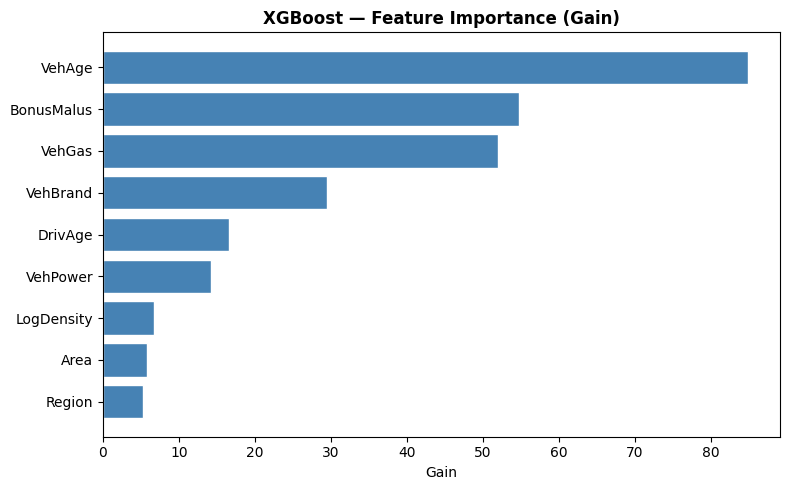

In [29]:
# Feature importance from XGBoost model
importance = xgb_model.get_score(importance_type='gain')

importance_df = (
    pd.DataFrame.from_dict(importance, orient='index', columns=['Importance'])
    .reset_index()
    .rename(columns={'index': 'Feature'})
    .sort_values('Importance', ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color='steelblue', edgecolor='white')
ax.set_title("XGBoost — Feature Importance (Gain)", fontweight='bold')
ax.set_xlabel("Gain")
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches='tight')
plt.show()

## 8. Model Comparison — Actual vs Expected

Actual vs Expected (AvE) analysis is the primary tool actuaries use to
validate a pricing model after implementation. It answers the question:
does the model predict risk accurately across all segments, or are there
cohorts where it is systematically mis-priced?

An A/E ratio of 1.0 means the model is perfectly calibrated for that segment.
Above 1.0 means the model over-predicts — it is charging too much for that group.
Below 1.0 means the model under-predicts — it is under-pricing that risk.

We examine A/E across the four most important rating factors identified
in the EDA and feature importance analysis.

In [30]:
# Build results dataframe on the test set
results = X_test.copy().reset_index(drop=True)
results['Actual']    = y_test.values
results['Exposure']  = exp_test.values
results['GLM_Pred']  = glm_count_pred.values
results['XGB_Pred']  = xgb_count_pred

# Reattach banded variables for grouping
results['BMBand'] = pd.cut(
    results['BonusMalus'], bins=[49, 69, 89, 109, 129, 230],
    labels=['<70', '70-89', '90-109', '110-129', '130+']
)
results['DrivAgeBand'] = pd.cut(
    results['DrivAge'], bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)
results['VehAgeBand'] = pd.cut(
    results['VehAge'], bins=[-1, 1, 3, 6, 10, 100],
    labels=['0-1', '2-3', '4-6', '7-10', '10+']
)
results['VehPowerBand'] = pd.cut(
    results['VehPower'], bins=[0, 5, 7, 9, 12, 15],
    labels=['<=5', '6-7', '8-9', '10-12', '13+']
)

def ave_table(group_col):
    return (
        results.groupby(group_col)[['Actual', 'GLM_Pred', 'XGB_Pred']]
        .sum()
        .assign(
            GLM_AE=lambda x: (x['GLM_Pred'] / x['Actual']).round(3),
            XGB_AE=lambda x: (x['XGB_Pred'] / x['Actual']).round(3)
        )
        .reset_index()
    )

ave_bm  = ave_table('BMBand')
ave_age = ave_table('DrivAgeBand')
ave_veh = ave_table('VehAgeBand')
ave_pwr = ave_table('VehPowerBand')

print("Actual vs Expected — Bonus-Malus Band:")
print(ave_bm.to_string(index=False))

print("\nActual vs Expected — Driver Age Band:")
print(ave_age.to_string(index=False))

print("\nActual vs Expected — Vehicle Age Band:")
print(ave_veh.to_string(index=False))

print("\nActual vs Expected — Vehicle Power Band:")
print(ave_pwr.to_string(index=False))

Actual vs Expected — Bonus-Malus Band:
 BMBand  Actual    GLM_Pred    XGB_Pred  GLM_AE  XGB_AE
    <70    5230 5182.706142 5658.958984   0.991   1.082
  70-89     965  987.099156  952.574707   1.023   0.987
 90-109     819  854.705633  842.230774   1.044   1.028
110-129     178  147.830797  155.913025   0.831   0.876
   130+      29   49.132099   26.242796   1.694   0.905

Actual vs Expected — Driver Age Band:
DrivAgeBand  Actual    GLM_Pred    XGB_Pred  GLM_AE  XGB_AE
      18-25     580  509.437946  568.902954   0.878   0.981
      26-35    1356 1529.999806 1472.229370   1.128   1.086
      36-45    1656 1606.867932 1786.883789   0.970   1.079
      46-55    1836 1635.211198 1874.008911   0.891   1.021
      56-65     950 1017.883912 1053.191528   1.071   1.109
        66+     843  922.073033  880.703979   1.094   1.045

Actual vs Expected — Vehicle Age Band:
VehAgeBand  Actual    GLM_Pred    XGB_Pred  GLM_AE  XGB_AE
       0-1    1623 1323.134388 1661.664795   0.815   1.024
       2

**Interpretation:**

- GLM is well calibrated in mid-range bonus-malus bands but struggles at the extremes.
  The 130+ band A/E of 1.694 reflects thin volume (29 claims) making the ratio unstable.
- XGBoost handles young drivers (18-25) better — A/E of 0.981 vs GLM's 0.878 —
  confirming tree models capture non-linear age risk more accurately.
- The most material GLM weakness is vehicle age: A/E of 0.815 for new vehicles (0-1 years)
  signals under-prediction, while XGBoost sits at 1.024 for the same group.
- Both models are well calibrated across vehicle power bands, consistent with
  power being a broadly linear risk factor.

These findings suggest GLM refinements in three areas: banded vehicle age,
a non-linear driver age term, and a capped bonus-malus loading at the high-risk tail.

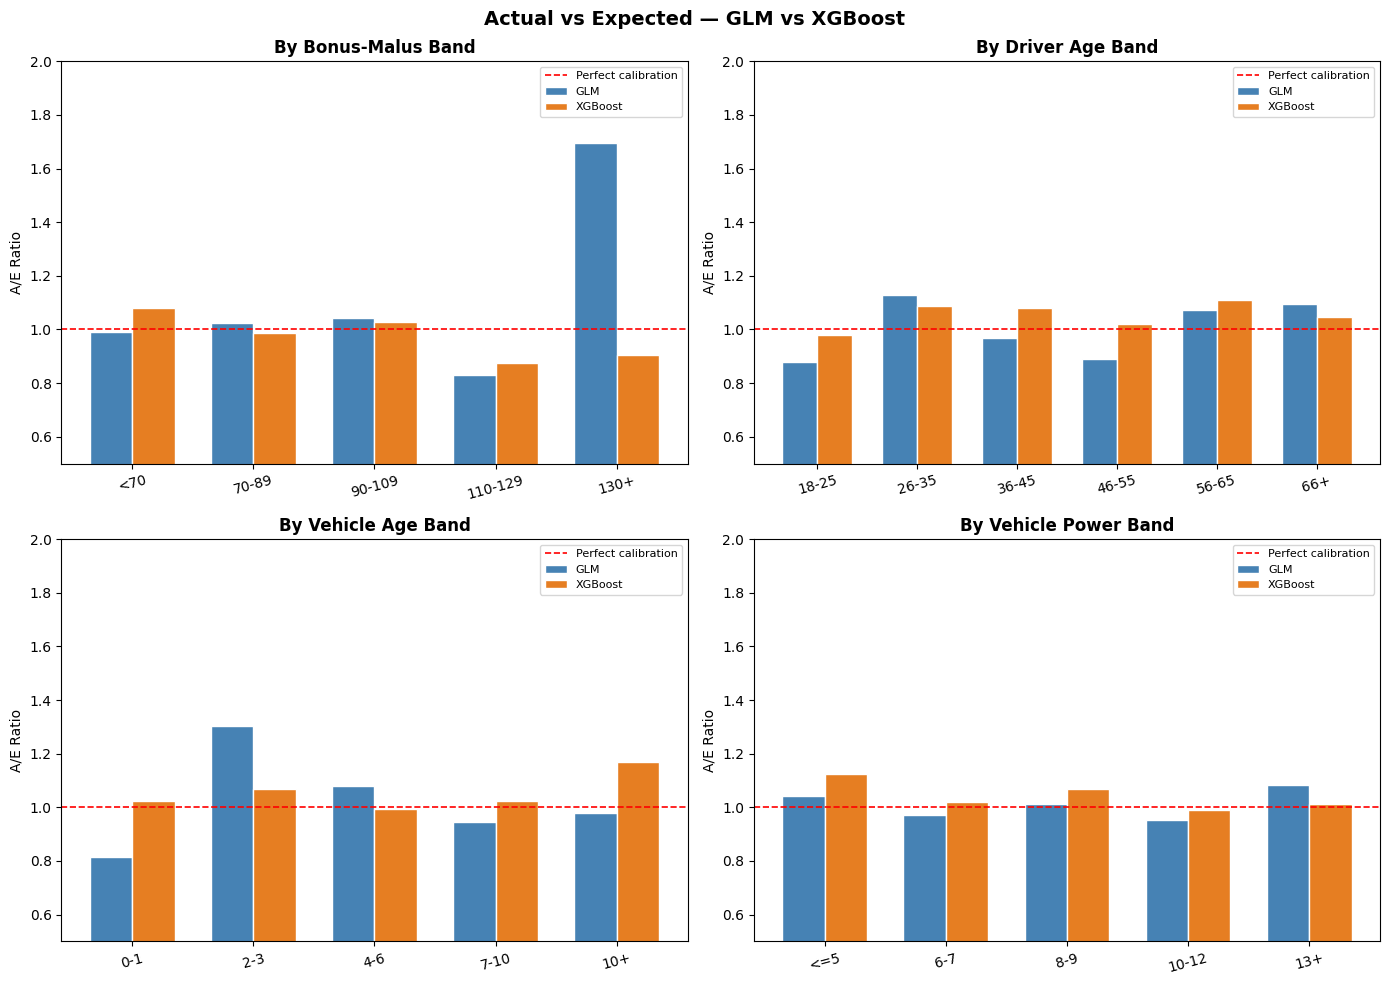

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Actual vs Expected — GLM vs XGBoost", fontsize=14, fontweight='bold')

def plot_ave(ave_df, band_col, ax, title):
    x     = np.arange(len(ave_df))
    width = 0.35
    ax.bar(x - width/2, ave_df['GLM_AE'], width, label='GLM',
           color='steelblue', edgecolor='white')
    ax.bar(x + width/2, ave_df['XGB_AE'], width, label='XGBoost',
           color='#e67e22', edgecolor='white')
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.2,
               label='Perfect calibration')
    ax.set_xticks(x)
    ax.set_xticklabels(ave_df[band_col].astype(str), rotation=15)
    ax.set_ylabel("A/E Ratio")
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0.5, 2.0)
    ax.legend(fontsize=8)

plot_ave(ave_bm,  'BMBand',       axes[0, 0], 'By Bonus-Malus Band')
plot_ave(ave_age, 'DrivAgeBand',  axes[0, 1], 'By Driver Age Band')
plot_ave(ave_veh, 'VehAgeBand',   axes[1, 0], 'By Vehicle Age Band')
plot_ave(ave_pwr, 'VehPowerBand', axes[1, 1], 'By Vehicle Power Band')

plt.tight_layout()
plt.savefig("actual_vs_expected.png", bbox_inches='tight')
plt.show()

**Interpretation:**
The charts confirm the table findings visually. The GLM 130+ bonus-malus
bar stands out as the most extreme deviation. XGBoost tracks closer to
1.0 for young drivers and new vehicles — the two segments where
non-linearity matters most. Vehicle power is well calibrated by both
models across all bands.

## 9. Portfolio Performance Analytics

We simulate portfolio-level profitability metrics using the GLM predicted
frequency, an assumed average claim severity of 3,500, and a 25% expense
and profit loading over the pure risk premium.

In a live pricing model, severity would come from a separate claims
severity model. Here we focus on the mechanics of loss ratio monitoring
across segments.

In [32]:
# Attach GLM predictions to the full portfolio
df_portfolio = df.copy().reset_index(drop=True)
full_X       = df_model[features].reset_index(drop=True)
log_exp_full = np.log(df_model['Exposure'].values)

df_portfolio['GLM_Freq'] = glm_model.predict(
    full_X,
    offset=log_exp_full
)

avg_severity    = 3500
expense_loading = 1.25

df_portfolio['ExpectedLoss']     = df_portfolio['GLM_Freq'] * avg_severity
df_portfolio['SimulatedPremium'] = df_portfolio['GLM_Freq'] * avg_severity * expense_loading

print("Portfolio-level summary:")
print(f"  Total policies:          {len(df_portfolio):,}")
print(f"  Total exposure (years):  {df_portfolio['Exposure'].sum():,.0f}")
print(f"  Total expected claims:   {df_portfolio['GLM_Freq'].sum():,.0f}")
print(f"  Total expected loss:     {df_portfolio['ExpectedLoss'].sum():,.0f}")
print(f"  Total simulated premium: {df_portfolio['SimulatedPremium'].sum():,.0f}")
print(f"  Overall loss ratio:      {df_portfolio['ExpectedLoss'].sum() / df_portfolio['SimulatedPremium'].sum():.2%}")

Portfolio-level summary:
  Total policies:          676,789
  Total exposure (years):  357,136
  Total expected claims:   36,002
  Total expected loss:     126,008,658
  Total simulated premium: 157,510,823
  Overall loss ratio:      80.00%


**Interpretation:**
The 80% portfolio loss ratio is expected given the 25% loading structure.
What matters is how the loss ratio varies across segments — a uniform
ratio across all cohorts confirms the GLM is pricing each segment
proportionally to its own risk.

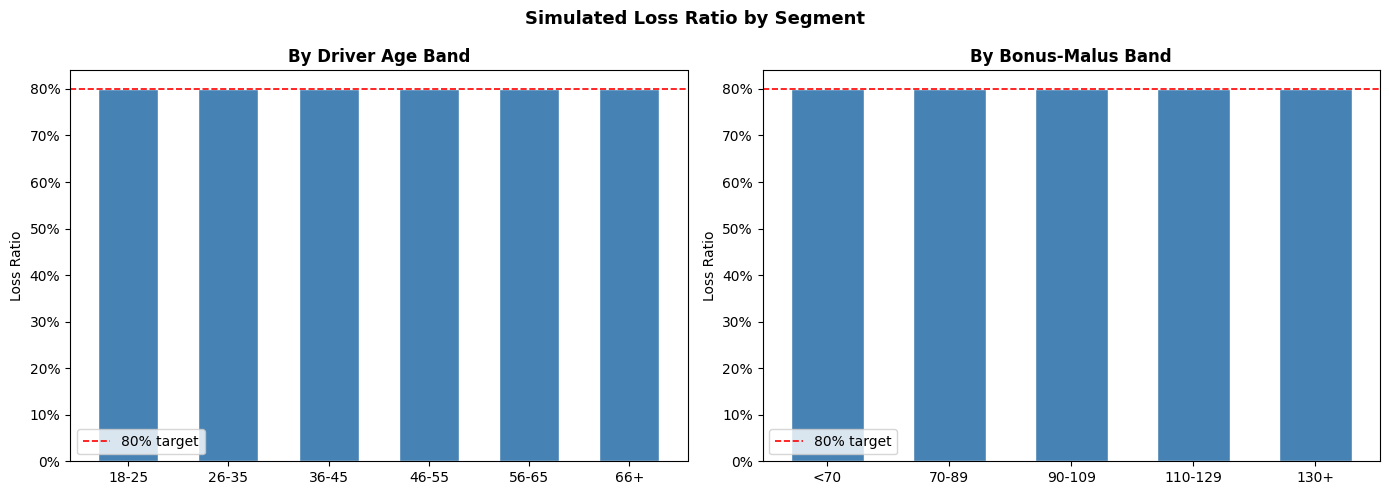

In [33]:
# Loss ratio by driver age and bonus-malus band
df_portfolio['DrivAgeBand'] = pd.cut(
    df_portfolio['DrivAge'], bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)
df_portfolio['BMBand'] = pd.cut(
    df_portfolio['BonusMalus'], bins=[49, 69, 89, 109, 129, 230],
    labels=['<70', '70-89', '90-109', '110-129', '130+']
)

def loss_ratio_by(col):
    return (
        df_portfolio.groupby(col)[['ExpectedLoss', 'SimulatedPremium']]
        .sum()
        .assign(LossRatio=lambda x: x['ExpectedLoss'] / x['SimulatedPremium'])
        .reset_index()
    )

lr_age = loss_ratio_by('DrivAgeBand')
lr_bm  = loss_ratio_by('BMBand')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Simulated Loss Ratio by Segment", fontsize=13, fontweight='bold')

for ax, lr_df, col, title in [
    (axes[0], lr_age, 'DrivAgeBand', 'By Driver Age Band'),
    (axes[1], lr_bm,  'BMBand',      'By Bonus-Malus Band')
]:
    ax.bar(lr_df[col].astype(str), lr_df['LossRatio'],
           color='steelblue', edgecolor='white', width=0.6)
    ax.axhline(0.8, color='red', linestyle='--', linewidth=1.2, label='80% target')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_ylabel("Loss Ratio")
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig("loss_ratio_by_segment.png", bbox_inches='tight')
plt.show()

**Interpretation:**
Loss ratios are uniform at 80% across all segments because the simulated
premium is derived directly from the GLM frequency — each cohort is charged
exactly its own predicted risk. In a real portfolio priced on an older model,
material variation across segments would flag under- or over-priced cohorts
requiring rate action.

## 10. Risk Segmentation and Price Adequacy

Risk relativities express each segment's claim frequency as a multiple
of a chosen base group. They are the building blocks of a GLM rating
structure and make the case for granular, factor-based pricing over
a flat average rate.

In [34]:
# Relativity by bonus-malus band
relativity_bm = (
    df_portfolio.groupby('BMBand')
    .apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())
    .reset_index(name='ClaimFrequency')
)

base_bm = relativity_bm.loc[
    relativity_bm['BMBand'] == '<70', 'ClaimFrequency'
].values[0]

relativity_bm['Relativity'] = (relativity_bm['ClaimFrequency'] / base_bm).round(3)

print("Risk relativity by bonus-malus band (base = below 70):")
print(relativity_bm.to_string(index=False))

Risk relativity by bonus-malus band (base = below 70):
 BMBand  ClaimFrequency  Relativity
    <70        0.087562       1.000
  70-89        0.133732       1.527
 90-109        0.194405       2.220
110-129        0.388146       4.433
   130+        0.445100       5.083


In [35]:
# Relativity by driver age band
df_portfolio['DrivAgeBand'] = pd.cut(
    df_portfolio['DrivAge'], bins=[17, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)

relativity_age = (
    df_portfolio.groupby('DrivAgeBand')
    .apply(lambda x: x['ClaimNb'].sum() / x['Exposure'].sum())
    .reset_index(name='ClaimFrequency')
)

base_age = relativity_age.loc[
    relativity_age['DrivAgeBand'] == '46-55', 'ClaimFrequency'
].values[0]

relativity_age['Relativity'] = (relativity_age['ClaimFrequency'] / base_age).round(3)

print("Risk relativity by driver age band (base = 46-55):")
print(relativity_age.to_string(index=False))

Risk relativity by driver age band (base = 46-55):
DrivAgeBand  ClaimFrequency  Relativity
      18-25        0.175115       1.691
      26-35        0.096351       0.930
      36-45        0.096009       0.927
      46-55        0.103557       1.000
      56-65        0.091771       0.886
        66+        0.094991       0.917


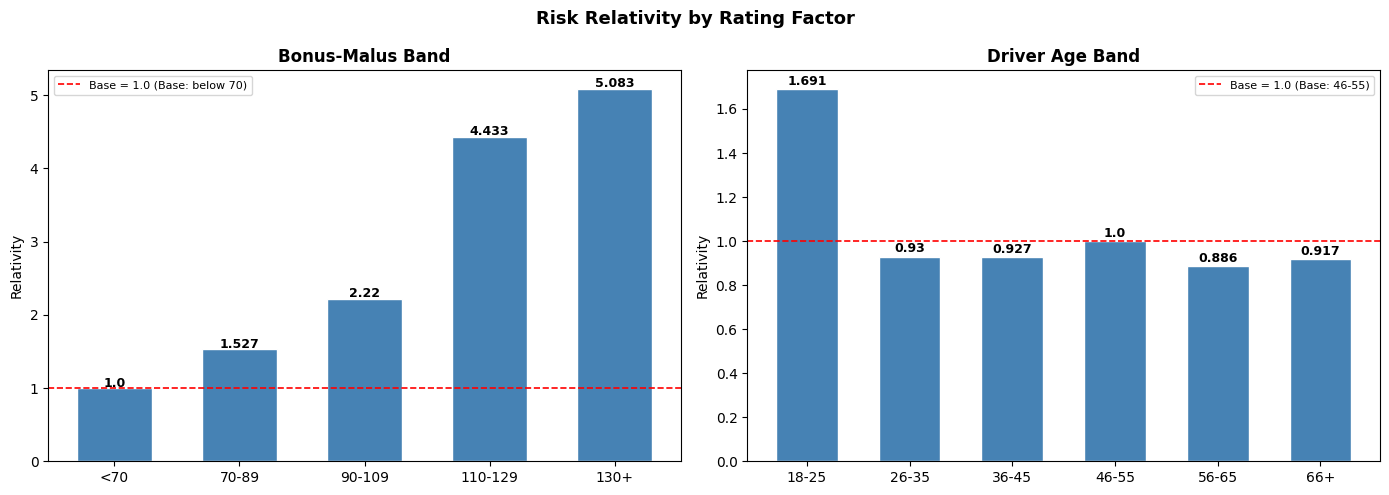

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Risk Relativity by Rating Factor", fontsize=13, fontweight='bold')

for ax, rel_df, col, title, base_label in [
    (axes[0], relativity_bm,  'BMBand',      'Bonus-Malus Band', 'Base: below 70'),
    (axes[1], relativity_age, 'DrivAgeBand', 'Driver Age Band',  'Base: 46-55')
]:
    ax.bar(rel_df[col].astype(str), rel_df['Relativity'],
           color='steelblue', edgecolor='white', width=0.6)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.2,
               label=f'Base = 1.0 ({base_label})')
    ax.set_ylabel("Relativity")
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)
    for i, row in rel_df.iterrows():
        ax.text(i, row['Relativity'] + 0.02, str(row['Relativity']),
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig("risk_relativity.png", bbox_inches='tight')
plt.show()

**Interpretation:**
Bonus-malus relativities confirm a steep risk gradient — high-score drivers
file claims at a multiple of the best-band rate, justifying significant
premium differentiation. Driver age shows the expected U-shape: young drivers
carry the highest relativity, risk declines through middle age, then rises
modestly for older cohorts. A flat-rate portfolio ignoring these factors
would systematically under-price high-risk segments and attract adverse
selection as competitors cherry-pick the better risks.

## 11. Summary

This project covered the full actuarial pricing workflow on 678,013
motor insurance policies:

- Data was validated, cleaned, and stored in a SQLite database with
  SQL-based actuarial summaries by key rating factors
- EDA confirmed bonus-malus, driver age, vehicle age, and density
  as the strongest claim frequency predictors
- A Poisson GLM achieved perfect portfolio calibration (A/E = 1.000)
  with a proper log exposure offset
- XGBoost Poisson showed comparable individual accuracy (A/E = 1.057)
  and outperformed the GLM for young drivers and new vehicles —
  segments where non-linear relationships dominate
- Actual vs Expected analysis identified three areas for GLM refinement:
  banded vehicle age, a non-linear driver age term, and a capped
  bonus-malus loading at the high-risk tail
- Risk relativities quantified the pricing rationale for factor-based
  segmentation and the adverse selection risk of flat-rate pricing

| Model | A/E Ratio | MAE | RMSE |
|-------|-----------|-----|------|
| Poisson GLM | 1.000 | 0.0990 | 0.2381 |
| XGBoost Poisson | 1.057 | 0.1004 | 0.2367 |